# IND320 Project, assignment 1

By: Ole Andreas Grøtting\
Github: IND320 - OLEGRO99\
Streamlit: 

### Imports

In [31]:
import pandas as pd
import streamlit as st
import matplotlib.pyplot as plt
import numpy as np

In [21]:
%matplotlib inline

### load the dataset

In [27]:
reservoirs = pd.read_csv("data/reservoirs.csv", sep = ",")
reservoirs.head()
#we can see that some of the dates in "neste publiseringsdato" are set to 1 of january year 1.

,dato_Id,omrType,omrnr,iso_aar,iso_uke,fyllingsgrad,kapasitet_TWh,fylling_TWh,neste_Publiseringsdato,fyllingsgrad_forrige_uke,endring_fyllingsgrad
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


## data cleaning

In [28]:
reservoirs = reservoirs.rename(columns={"dato_Id": "Date", 
                                        "omrType": "Region",
                                        "omrnr": "Region_Number",
                                        "iso_aar": "iso_year", 
                                        "iso_uke": "iso_week",
                                        "fyllingsgrad": "filling_level",
                                        "kapasitet_TWh": "Capacity(TWh)", 
                                        "fylling_TWh": "Filled (TWh)",
                                        "neste_Publiseringsdato": "Next_Publication_Date",
                                        "fyllingsgrad_forrige_uke": "filling_level_previous_week",
                                        "endring_fyllingsgrad": "change_filling_level"
})
reservoirs.head()

,Date,Region,Region_Number,iso_year,iso_week,filling_level,Capacity(TWh),Filled (TWh),Next_Publication_Date,filling_level_previous_week,change_filling_level
0,1995-09-03,EL,4,1995,35,0.944721,21.079208,19.913979,0001-01-01T00:00:00,0.936888,0.007833
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25T13:00:00,0.997406,-0.023046
2,2011-08-28,EL,4,2011,34,0.786499,21.079208,16.578772,0001-01-01T00:00:00,0.787193,-0.000694
3,1998-07-05,EL,3,1998,27,0.793969,8.920932,7.082947,0001-01-01T00:00:00,0.733812,0.060157
4,2011-03-27,EL,4,2011,12,0.300820,21.079208,6.341054,0001-01-01T00:00:00,0.311122,-0.010301


In [30]:
reservoirs['Next_Publication_Date'] = pd.to_datetime(reservoirs['Next_Publication_Date'], errors='coerce')
reservoirs.loc[
    reservoirs["Next_Publication_Date"].dt.year == 1,
    "Next_Publication_Date"
] = pd.NaT
reservoirs = reservoirs.dropna(subset=["Next_Publication_Date"])
reservoirs.head()
# removing the rows with the year 1 in "neste publiseringsdato" and dropping the rows with NaT values in "neste publiseringsdato"

,Date,Region,Region_Number,iso_year,iso_week,filling_level,Capacity(TWh),Filled (TWh),Next_Publication_Date,filling_level_previous_week,change_filling_level
1,2020-11-15,EL,1,2020,46,0.974361,6.003264,5.849344,2020-11-25 13:00:00,0.997406,-0.023046
9,2023-08-13,EL,5,2023,32,0.836849,17.390587,14.553301,2023-08-23 13:00:00,0.776765,0.060084
12,2021-04-18,EL,5,2021,15,0.246682,17.390587,4.289936,2021-04-28 13:00:00,0.276825,-0.030144
13,2019-06-02,EL,1,2019,22,0.659981,6.003264,3.962040,2019-06-12 13:00:00,0.625398,0.034583
15,2019-10-27,EL,1,2019,43,0.896057,6.003264,5.379270,2019-11-06 13:00:00,0.882742,0.013315


In [35]:
reservoirs.info()
reservoirs.describe()

<class 'pandas.DataFrame'>
Index: 3555 entries, 1 to 14876
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   Date                         3555 non-null   str           
 1   Region                       3555 non-null   str           
 2   Region_Number                3555 non-null   int64         
 3   iso_year                     3555 non-null   int64         
 4   iso_week                     3555 non-null   int64         
 5   filling_level                3555 non-null   float64       
 6   Capacity(TWh)                3555 non-null   float64       
 7   Filled (TWh)                 3555 non-null   float64       
 8   Next_Publication_Date        3555 non-null   datetime64[us]
 9   filling_level_previous_week  3555 non-null   float64       
 10  change_filling_level         3555 non-null   float64       
dtypes: datetime64[us](1), float64(5), int64(3), str(2)
memory 

,Region_Number,iso_year,iso_week,filling_level,Capacity(TWh),Filled (TWh),Next_Publication_Date,filling_level_previous_week,change_filling_level
count,3555.000000,3555.000000,3555.000000,3555.000000,3555.000000,3555.000000,3555,3555.000000,3555.000000
mean,2.333333,2022.405063,26.187342,0.612520,29.145860,17.859596,2022-12-07 13:21:52.405063,0.612048,0.000473
min,0.000000,2019.000000,1.000000,0.080855,6.003264,0.485396,2019-02-27 13:00:00,0.080855,-0.061430
25%,1.000000,2020.000000,14.000000,0.458974,17.390587,7.312559,2021-01-13 13:00:00,0.457667,-0.021610
50%,2.000000,2022.000000,26.000000,0.638860,23.237715,14.420002,2022-12-07 13:00:00,0.637976,-0.006449
75%,3.000000,2024.000000,39.000000,0.785713,34.043590,21.913880,2024-10-30 13:00:00,0.785222,0.016729
max,5.000000,2026.000000,53.000000,1.020072,87.437580,83.699460,2026-09-16 13:00:00,1.020037,0.195565
std,1.490922,2.203409,14.727589,0.209919,22.741505,15.566634,NaN,0.209927,0.031425


## plotting the data

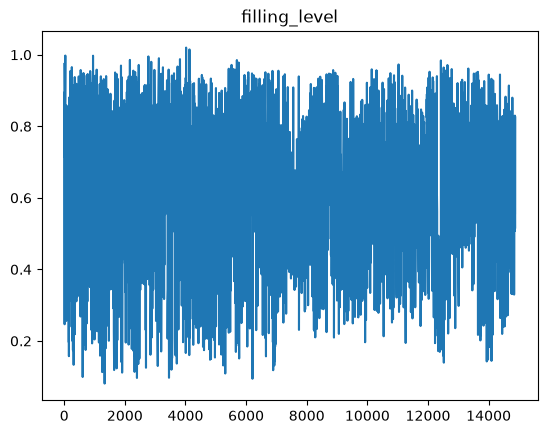

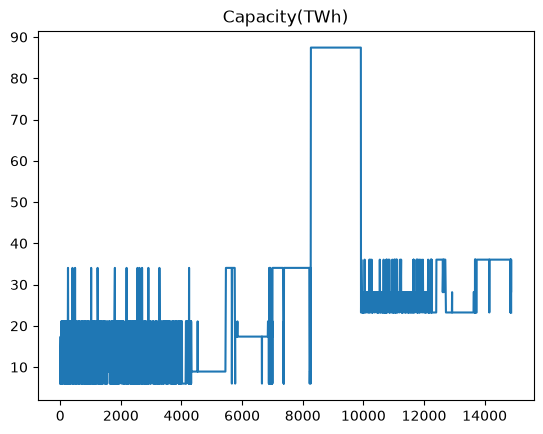

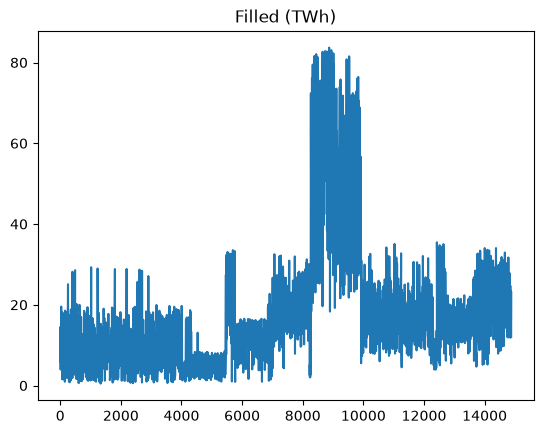

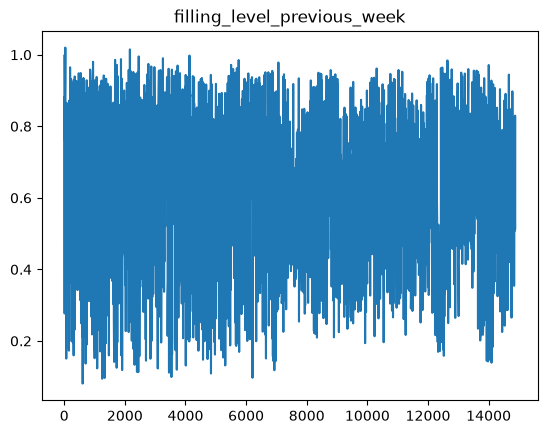

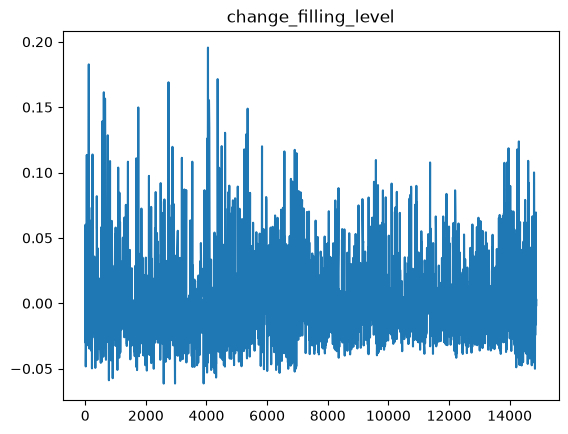

In [34]:
reservoirs["filling_level"].plot()
plt.title("filling_level")
plt.show()

reservoirs["Capacity(TWh)"].plot()
plt.title("Capacity(TWh)")
plt.show()

reservoirs["Filled (TWh)"].plot()
plt.title("Filled (TWh)")
plt.show()

reservoirs["filling_level_previous_week"].plot()
plt.title("filling_level_previous_week")
plt.show()

reservoirs["change_filling_level"].plot()
plt.title("change_filling_level")
plt.show()